Mounted at /content/drive
Reconstituting processed features from: /content/drive/MyDrive/Colab Notebooks/processed_features_1M.parquet
Initializing XGBoost GPU training pipeline...
Model training completed.

--- Model Performance Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.34      0.46      3075
           1       0.92      0.94      0.93    153333
           2       0.73      0.69      0.71     43592

    accuracy                           0.88    200000
   macro avg       0.78      0.66      0.70    200000
weighted avg       0.87      0.88      0.87    200000


Executing SHAP explainability protocol...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Beeswarm plot generated and downloaded.
Final predictions saved to: /content/drive/MyDrive/Colab Notebooks/Burnout_Predictions_Final_1M.csv


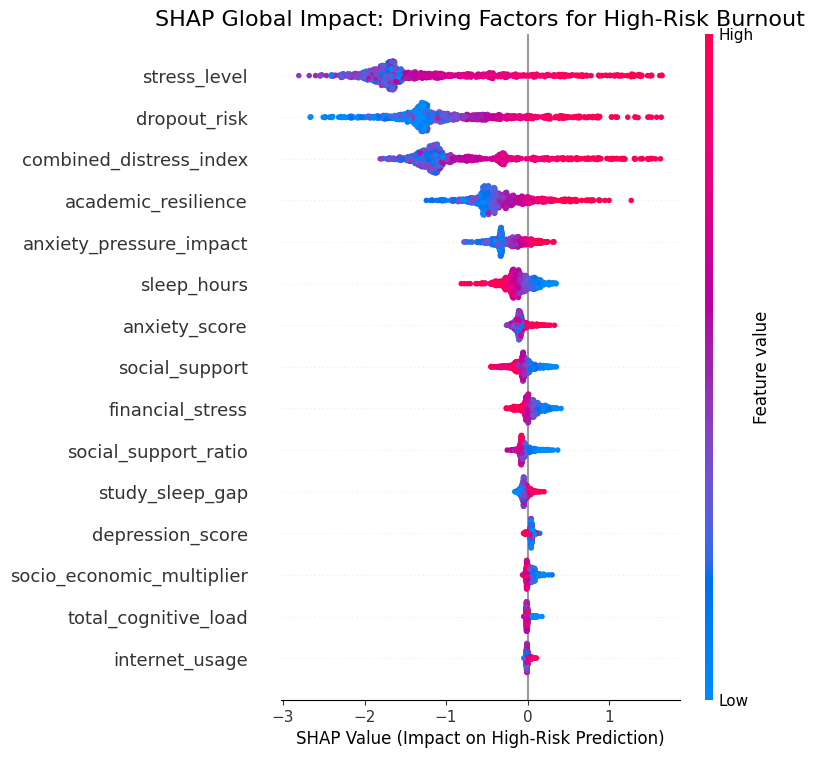

In [4]:
# -----------------------------------------------------------------------------
# PROJECT: STUDENT WELL-BEING ANALYTICS (1M RECORDS)
# COMPONENT: TASK 2 - ADVANCED PREDICTIVE MODELING & INTERPRETABILITY (REFINED)
# ENVIRONMENT: GOOGLE COLAB (T4 GPU)
# -----------------------------------------------------------------------------

!pip install -q shap xgboost cudf-cu12

import cudf
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import os
from google.colab import drive, files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def run_ml_interpretability_pipeline():
    # 1. DATA RECONSTITUTION
    # -------------------------------------------------------------------------
    drive.mount('/content/drive', force_remount=True)
    INPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/processed_features_1M.parquet"

    print(f"Reconstituting processed features from: {INPUT_PATH}")
    if not os.path.exists(INPUT_PATH):
        print("Error: Parquet file not found. Please execute Task 1 first.")
        return

    gdf = cudf.read_parquet(INPUT_PATH)

    # Target Variable Encoding
    gdf['target'] = gdf['risk_level'].astype('category').cat.codes
    X = gdf.drop(['risk_level', 'target', 'burnout_score', 'mental_health_index'], axis=1).select_dtypes('number')
    y = gdf['target']

    # 2. MODEL SPECIFICATION (XGBoost 2.0+ Syntax)
    # -------------------------------------------------------------------------
    print("Initializing XGBoost GPU training pipeline...")
    X_pd = X.to_pandas()
    y_pd = y.to_pandas()
    X_train, X_test, y_train, y_test = train_test_split(X_pd, y_pd, test_size=0.2, random_state=42)

    model = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )

    model.fit(X_train, y_train)
    print("Model training completed.")

    # 3. PERFORMANCE REPORT
    # -------------------------------------------------------------------------
    predictions = model.predict(X_test)
    print("\n--- Model Performance Classification Report ---")
    print(classification_report(y_test, predictions))

    # 4. MODEL INTERPRETABILITY (FIXED FOR XGBOOST 2.0 SHAPE)
    # -------------------------------------------------------------------------
    print("\nExecuting SHAP explainability protocol...")
    explainer = shap.TreeExplainer(model)
    X_test_sample = X_test.iloc[:1000]
    shap_values = explainer.shap_values(X_test_sample)

    # FIX: Check shape correctly. Multiclass shape is usually (n_samples, n_features, n_classes)
    if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
        # Slice along the class dimension (last dimension) for class 0
        shap_values_to_plot = shap_values[:, :, 0]
    elif isinstance(shap_values, list):
        shap_values_to_plot = shap_values[0]
    else:
        shap_values_to_plot = shap_values

    plt.figure(figsize=(12, 10))
    shap.summary_plot(
        shap_values_to_plot,
        X_test_sample,
        show=False,
        plot_type="dot",
        max_display=15
    )

    plt.title("SHAP Global Impact: Driving Factors for High-Risk Burnout", fontsize=16)
    plt.xlabel("SHAP Value (Impact on High-Risk Prediction)", fontsize=12)

    plt.savefig("interpretability_summary_beeswarm.png", bbox_inches='tight', dpi=300)
    files.download("interpretability_summary_beeswarm.png")
    print("Beeswarm plot generated and downloaded.")

    # 5. DATASET EXPORT
    # -------------------------------------------------------------------------
    full_predictions = gdf.to_pandas()
    full_predictions['predicted_risk_index'] = model.predict(X_pd)
    label_map = {0: 'High', 1: 'Low', 2: 'Medium'}
    full_predictions['predicted_risk_label'] = full_predictions['predicted_risk_index'].map(label_map)
    CSV_OUTPUT = "/content/drive/MyDrive/Colab Notebooks/Burnout_Predictions_Final_1M.csv"
    full_predictions.to_csv(CSV_OUTPUT, index=False)
    print(f"Final predictions saved to: {CSV_OUTPUT}")

if __name__ == "__main__":
    run_ml_interpretability_pipeline()